In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.sql import functions as F

from pyspark.sql import SparkSession
from pyspark.ml.feature import StringIndexer
from pyspark.sql.functions import col
from pyspark.ml.evaluation import RegressionEvaluator

# Set visual style for the charts
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [8]:
# SparkSession (like the wpo)
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("AnimeRecommender") \
    .config("spark.ui.port", "4040") \
    .config("spark.hadoop.fs.defaultFS", "file:///") \
    .config("spark.driver.extraJavaOptions", "-Duser.name=admin") \
    .config("spark.driver.extraJavaOptions", "-Dsun.security.auth.login.config=C:/dev/null") \
    .getOrCreate()

In [9]:
#pre processed data

reviews_data = spark.read.csv("../data/preprocessed/reviews.csv", header=True, inferSchema=True)
anime_data = spark.read.csv("../data/preprocessed/animes.csv", header=True, inferSchema=True)


review_indexed = StringIndexer(inputCol="profile", outputCol="user_id")
reviews_data_indexed = review_indexed.fit(reviews_data).transform(reviews_data)

start_data = reviews_data_indexed.select(
    col("user_id").cast("integer"),
    col("anime_id").cast("integer"),
    col("score").cast("float")
)

# final_data = clean_sparse_data(start_data, min_user_reviews=5, min_anime_reviews=10)



start_data.show(7)

+-------+--------+-----+
|user_id|anime_id|score|
+-------+--------+-----+
|     32|   34096|  8.0|
|   1104|   34599| 10.0|
|   1825|   28891|  7.0|
|   3796|    2904|  9.0|
|   9589|    4181| 10.0|
|   9872|    2904| 10.0|
|    554|   16664|  6.0|
+-------+--------+-----+
only showing top 7 rows



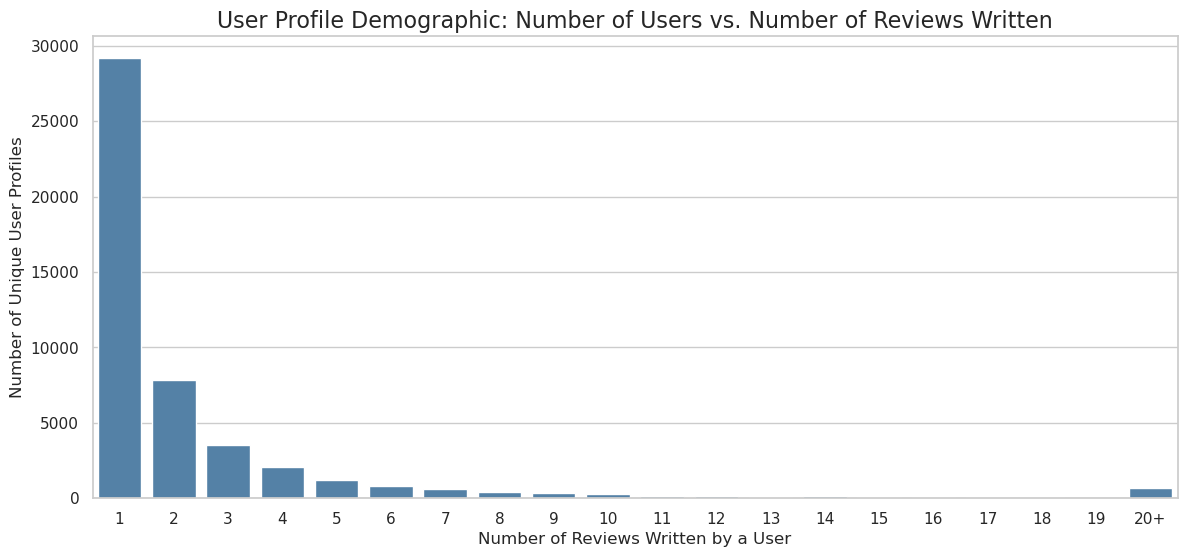

In [12]:

user_counts_df = start_data.groupBy("user_id").agg(F.count("anime_id").alias("review_count"))


user_distribution = user_counts_df.groupBy("review_count").agg(F.count("user_id").alias("num_users")).toPandas()


user_distribution['display_count'] = user_distribution['review_count'].apply(lambda x: str(x) if x < 20 else '20+')
chart1_data = user_distribution.groupby('display_count')['num_users'].sum().reset_index()


chart1_data['sort_key'] = chart1_data['display_count'].apply(lambda x: int(x) if x != '20+' else 999)
chart1_data = chart1_data.sort_values('sort_key')


plt.figure(figsize=(14, 6))
sns.barplot(data=chart1_data, x="display_count", y="num_users", color="steelblue")
plt.title("User Profile Demographic: Number of Users vs. Number of Reviews Written", fontsize=16)
plt.xlabel("Number of Reviews Written by a User", fontsize=12)
plt.ylabel("Number of Unique User Profiles", fontsize=12)
plt.xticks(rotation=0)
plt.show()

In [ ]:
%run ./collaborative_Final.ipynb

model, train_data, final_predictions = plot_train_model(min_user_reviews=0, min_anime_reviews=0)

In [9]:



user_counts = train_data.groupBy("user_id").agg(F.count("anime_id").alias("activity"))
df_perf = final_predictions.join(user_counts, on="user_id", how="inner")

df_perf = df_perf.withColumn("sq_err", (F.col("score") - F.col("final_prediction")) ** 2)

rmse_df = df_perf.groupBy("activity").agg(F.sqrt(F.avg("sq_err")).alias("rmse")).toPandas()

# 1. Update the bucket threshold to 70
rmse_df['bucket'] = rmse_df['activity'].apply(lambda x: str(x) if x <= 70 else '70+')

# Calculate the mean RMSE per bucket
chart_data = rmse_df.groupby('bucket')['rmse'].mean().reset_index()


def sort_buckets(val):
    if val == '70+': return 999
    return int(val)

chart_data['sort_key'] = chart_data['bucket'].apply(sort_buckets)
chart_data = chart_data.sort_values('sort_key').reset_index(drop=True)


plt.figure(figsize=(16, 6)) # Increased width for more x-axis values
sns.barplot(data=chart_data, x="bucket", y="rmse", color="steelblue")
plt.title("Granular RMSE Breakdown: Performance by Training Data Density", fontsize=16)
plt.xlabel("Number of Reviews per User", fontsize=12)
plt.ylabel("RMSE", fontsize=12)
plt.ylim(0, max(chart_data['rmse']) + 0.2)


plt.xticks(rotation=90) 
plt.show()

AttributeError: 'float' object has no attribute 'join'

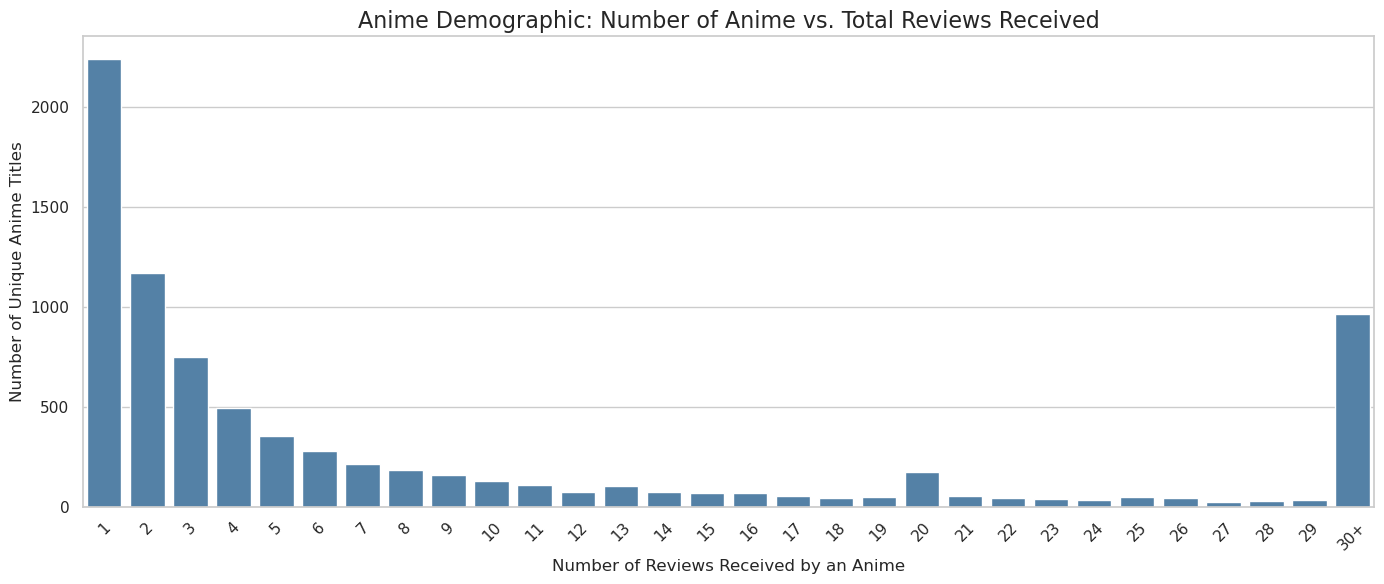

In [13]:

anime_counts_df = start_data.groupBy("anime_id").agg(F.count("user_id").alias("review_count"))


anime_distribution = anime_counts_df.groupBy("review_count").agg(F.count("anime_id").alias("num_animes")).toPandas()


anime_distribution['display_count'] = anime_distribution['review_count'].apply(lambda x: str(x) if x < 30 else '30+')
chart2_data = anime_distribution.groupby('display_count')['num_animes'].sum().reset_index()


chart2_data['sort_key'] = chart2_data['display_count'].apply(lambda x: int(x) if x != '30+' else 999)
chart2_data = chart2_data.sort_values('sort_key')


plt.figure(figsize=(14, 6))
sns.barplot(data=chart2_data, x="display_count", y="num_animes", color="steelblue")
plt.title("Anime Demographic: Number of Anime vs. Total Reviews Received", fontsize=16)
plt.xlabel("Number of Reviews Received by an Anime", fontsize=12)
plt.ylabel("Number of Unique Anime Titles", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Successfully saved PDF and PNG visualizations to the current working directory.


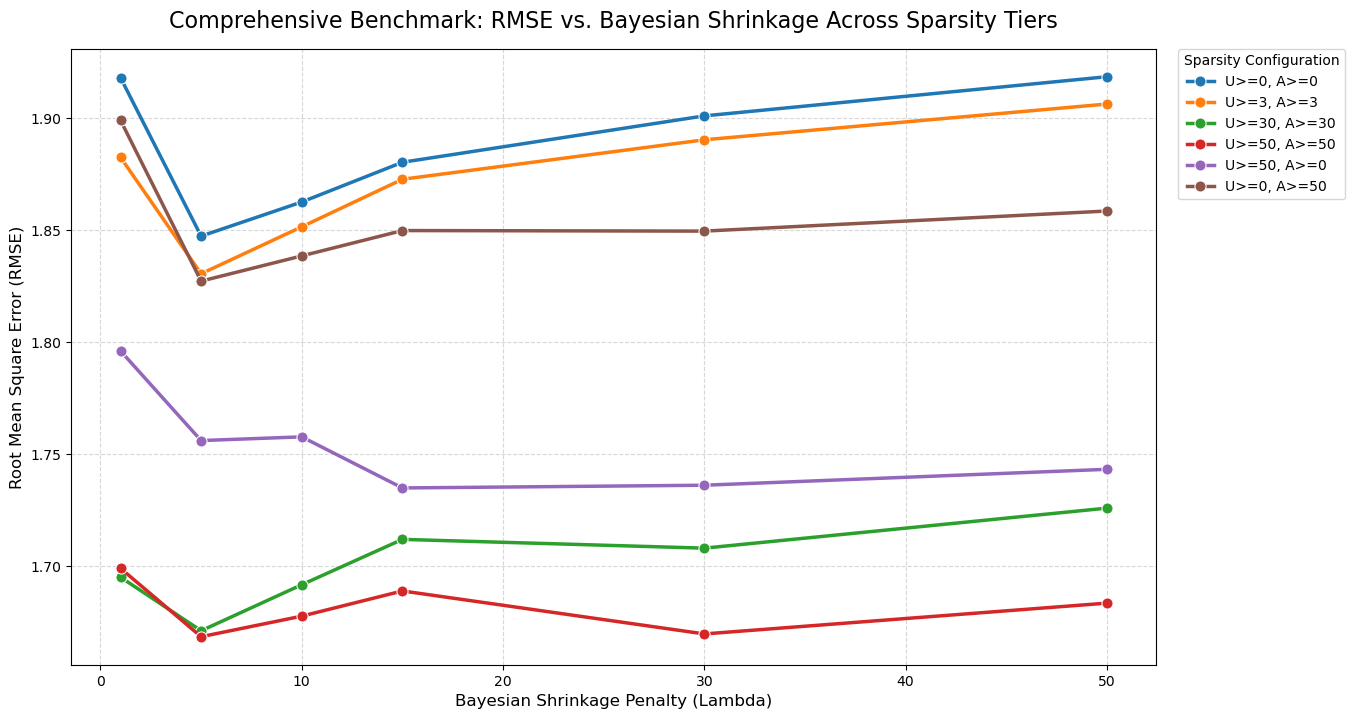

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


data = [

    ("U>=0, A>=0", 1.0, 1.917940),
    ("U>=0, A>=0", 5.0, 1.847270),
    ("U>=0, A>=0", 10.0, 1.862515),
    ("U>=0, A>=0", 15.0, 1.880251),
    ("U>=0, A>=0", 30.0, 1.900966),
    ("U>=0, A>=0", 50.0, 1.918447),
    

    ("U>=3, A>=3", 1.0, 1.882406),
    ("U>=3, A>=3", 5.0, 1.830463),
    ("U>=3, A>=3", 10.0, 1.851438),
    ("U>=3, A>=3", 15.0, 1.872659),
    ("U>=3, A>=3", 30.0, 1.890284),
    ("U>=3, A>=3", 50.0, 1.906256),
    

    ("U>=30, A>=30", 1.0, 1.694956),
    ("U>=30, A>=30", 5.0, 1.671067),
    ("U>=30, A>=30", 10.0, 1.691622),
    ("U>=30, A>=30", 15.0, 1.711870),
    ("U>=30, A>=30", 30.0, 1.707952),
    ("U>=30, A>=30", 50.0, 1.725827),
    
 
    ("U>=50, A>=50", 1.0, 1.698923),
    ("U>=50, A>=50", 5.0, 1.668403),
    ("U>=50, A>=50", 10.0, 1.677591),
    ("U>=50, A>=50", 15.0, 1.688842),
    ("U>=50, A>=50", 30.0, 1.669648),
    ("U>=50, A>=50", 50.0, 1.683408),
    
   -
    ("U>=50, A>=0", 1.0, 1.795977),
    ("U>=50, A>=0", 5.0, 1.755988),
    ("U>=50, A>=0", 10.0, 1.757643),
    ("U>=50, A>=0", 15.0, 1.734831),
    ("U>=50, A>=0", 30.0, 1.736042),
    ("U>=50, A>=0", 50.0, 1.743157),
    
  
    ("U>=0, A>=50", 1.0, 1.898936),
    ("U>=0, A>=50", 5.0, 1.827186),
    ("U>=0, A>=50", 10.0, 1.838441),
    ("U>=0, A>=50", 15.0, 1.849759),
    ("U>=0, A>=50", 30.0, 1.849513),
    ("U>=0, A>=50", 50.0, 1.858478),
]

# Convert dataset to a structured Pandas DataFrame
df = pd.DataFrame(data, columns=["Sparsity Filter", "Lambda", "RMSE"])


plt.figure(figsize=(14, 8))
sns.lineplot(
    data=df, 
    x="Lambda", 
    y="RMSE", 
    hue="Sparsity Filter", 
    marker="o", 
    linewidth=2.5, 
    markersize=8,
    palette="tab10" # Distinct color scheme for 6 categories
)


plt.title("Comprehensive Benchmark: RMSE vs. Bayesian Shrinkage Across Sparsity Tiers", fontsize=16, pad=15)
plt.xlabel("Bayesian Shrinkage Penalty (Lambda)", fontsize=12)
plt.ylabel("Root Mean Square Error (RMSE)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)


plt.legend(title="Sparsity Configuration", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)


pdf_save_path = "comprehensive_recommender_benchmark.pdf"
plt.savefig(pdf_save_path, format='pdf', bbox_inches='tight')

png_save_path = "comprehensive_recommender_benchmark.png"
plt.savefig(png_save_path, bbox_inches='tight', dpi=300)

print(f"Successfully saved PDF and PNG visualizations to the current working directory.")

# 5. Output to screen
plt.show()
plt.show()

Combined dashboard plots generated and saved successfully to PDF.


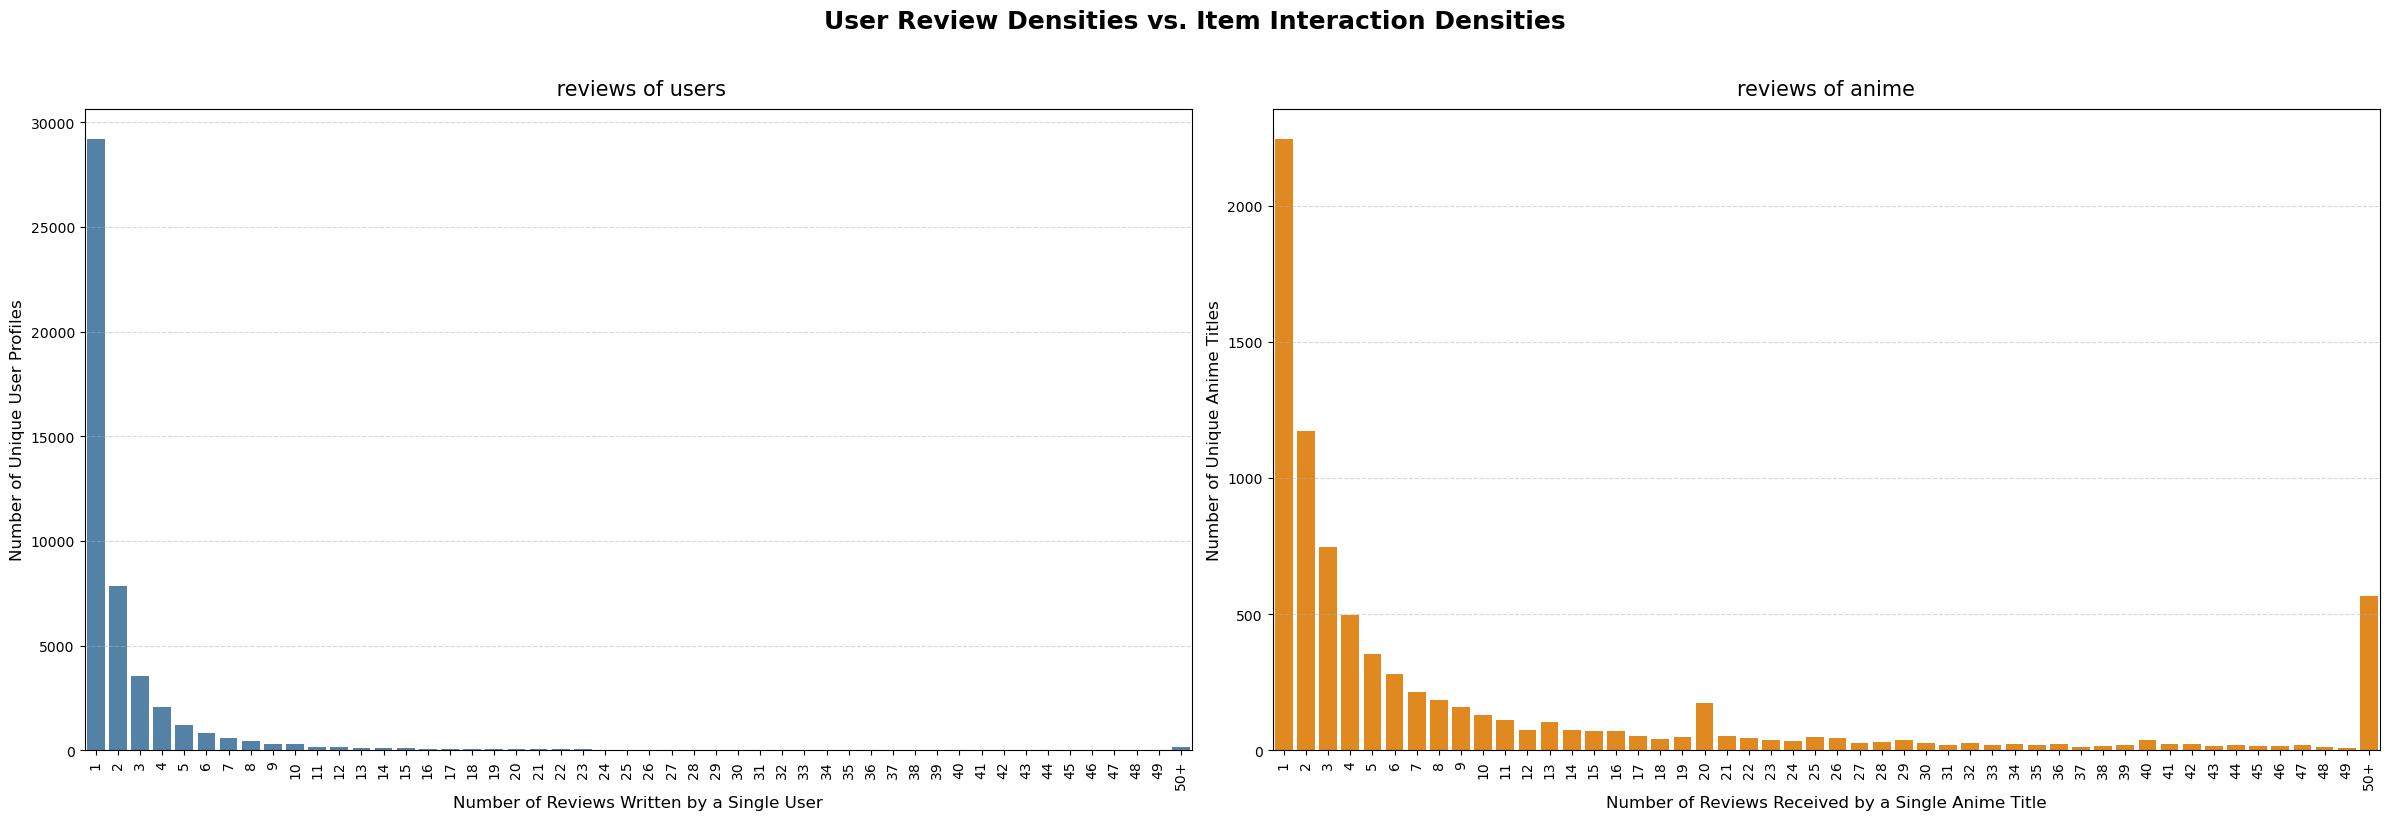

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

user_counts_df = start_data.groupBy("user_id").agg(F.count("anime_id").alias("review_count"))
user_distribution = user_counts_df.groupBy("review_count").agg(F.count("user_id").alias("num_users")).toPandas()

user_distribution['display_count'] = user_distribution['review_count'].apply(lambda x: str(x) if x < 50 else '50+')
chart1_data = user_distribution.groupby('display_count')['num_users'].sum().reset_index()

chart1_data['sort_key'] = chart1_data['display_count'].apply(lambda x: int(x) if x != '50+' else 999)
chart1_data = chart1_data.sort_values('sort_key').reset_index(drop=True)

anime_counts_df = start_data.groupBy("anime_id").agg(F.count("user_id").alias("review_count"))
anime_distribution = anime_counts_df.groupBy("review_count").agg(F.count("anime_id").alias("num_animes")).toPandas()

anime_distribution['display_count'] = anime_distribution['review_count'].apply(lambda x: str(x) if x < 50 else '50+')
chart2_data = anime_distribution.groupby('display_count')['num_animes'].sum().reset_index()

chart2_data['sort_key'] = chart2_data['display_count'].apply(lambda x: int(x) if x != '50+' else 999)
chart2_data = chart2_data.sort_values('sort_key').reset_index(drop=True)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(24, 8))

sns.barplot(data=chart1_data, x="display_count", y="num_users", color="steelblue", ax=axes[0])
axes[0].set_title(" reviews of users", fontsize=15, pad=10)
axes[0].set_xlabel("Number of Reviews Written by a Single User", fontsize=12)
axes[0].set_ylabel("Number of Unique User Profiles", fontsize=12)
axes[0].tick_params(axis='x', rotation=90) 
axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

sns.barplot(data=chart2_data, x="display_count", y="num_animes", color="darkorange", ax=axes[1])
axes[1].set_title("reviews of anime", fontsize=15, pad=10)
axes[1].set_xlabel("Number of Reviews Received by a Single Anime Title", fontsize=12)
axes[1].set_ylabel("Number of Unique Anime Titles", fontsize=12)
axes[1].tick_params(axis='x', rotation=90) 
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.suptitle("User Review Densities vs. Item Interaction Densities", fontsize=18, weight='bold', y=1.02)
plt.tight_layout()

plt.savefig("combined_sparsity_demographics.pdf", format='pdf', bbox_inches='tight')

print("Combined dashboard plots generated and saved successfully to PDF.")
plt.show()

In [16]:
import pyspark.sql.functions as F


total_ratings = start_data.count()


unique_users = start_data.select("user_id").distinct().count()
unique_anime = start_data.select("anime_id").distinct().count()


total_possible_ratings = unique_users * unique_anime


density = total_ratings / total_possible_ratings
sparsity = 1.0 - density


print(f"Total Actual Ratings: {total_ratings:,}")
print(f"Total Unique Users: {unique_users:,}")
print(f"Total Unique Anime: {unique_anime:,}")
print(f"Matrix Size (Possible Ratings): {total_possible_ratings:,}")
print("-" * 30)
print(f"Data Density: {density * 100:.4f}%")
print(f"Data Sparsity: {sparsity * 100:.4f}%")

Total Actual Ratings: 130,519
Total Unique Users: 47,885
Total Unique Anime: 8,113
Matrix Size (Possible Ratings): 388,491,005
------------------------------
Data Density: 0.0336%
Data Sparsity: 99.9664%


In [23]:


%run ./collaborative_Final.ipynb


model, predictions_df, model_rmse = plot_train_model(min_user_reviews=0, min_anime_reviews=0)


global_mean = train_data.agg(F.mean("score")).collect()[0][0]


baseline_predictions = predictions_df.withColumn("prediction", F.lit(global_mean))


evaluator = RegressionEvaluator(
    labelCol="score", 
    predictionCol="prediction", 
    metricName="rmse"
)

mean_rmse = evaluator.evaluate(baseline_predictions)


print(f"Global Mean Baseline RMSE: {mean_rmse:.4f}")
print(f"Your Model RMSE: {model_rmse:.4f}")

improvement = ((mean_rmse - model_rmse) / mean_rmse) * 100
print(f"Your model is {improvement:.2f}% better than the global mean.")

+-------+--------+-----+
|user_id|anime_id|score|
+-------+--------+-----+
|     32|   34096|  8.0|
|   1104|   34599| 10.0|
|   1825|   28891|  7.0|
|   3796|    2904|  9.0|
|   9589|    4181| 10.0|
|   9872|    2904| 10.0|
|    554|   16664|  6.0|
+-------+--------+-----+
only showing top 7 rows

hello
+-------+--------+-----+
|user_id|anime_id|score|
+-------+--------+-----+
|     32|   34096|  8.0|
|   1104|   34599| 10.0|
|   1825|   28891|  7.0|
|   3796|    2904|  9.0|
|   9589|    4181| 10.0|
|   9872|    2904| 10.0|
|    554|   16664|  6.0|
+-------+--------+-----+
only showing top 7 rows

Original Row Count: 130519
Cleaned Row Count: 130519
RMSE (With all bias + hyper para): 1.8625036302365974
Best Rank chosen: 100
Best RegParam chosen: 0.8
Lambda User: 10.0 | Lambda Item: 10.0
Global Mean Baseline RMSE: 2.2496
Your Model RMSE: 1.8625
Your model is 17.21% better than the global mean.


Original Row Count: 130519
Cleaned Row Count: 130519
RMSE (With all bias + hyper para): 1.8625036302365974
Best Rank chosen: 100
Best RegParam chosen: 0.8
Lambda User: 10.0 | Lambda Item: 10.0


AnalysisException: [AMBIGUOUS_REFERENCE] Reference `prediction` is ambiguous, could be: [`prediction`, `prediction`].

In [27]:
import pyspark.sql.functions as F
from pyspark.ml.evaluation import RegressionEvaluator

# 1. Run the model
model, preds_df, model_rmse = plot_train_model(min_user_reviews=0, min_anime_reviews=0)

# 2. Get the Average Score per anime
anime_means = train_data.groupBy("anime_id").agg(F.mean("score").alias("anime_avg"))

# 3. Create the Item-Average Baseline
# We drop 'prediction' from preds_df first to avoid the ambiguity
baseline_predictions = preds_df.drop("prediction") \
    .join(anime_means, on="anime_id", how="left") \
    .fillna(global_mean, subset=["anime_avg"]) \
    .withColumnRenamed("anime_avg", "prediction")

# 4. Evaluate the baseline
evaluator = RegressionEvaluator(
    labelCol="score", 
    predictionCol="prediction", 
    metricName="rmse"
)

mean_rmse = evaluator.evaluate(baseline_predictions)

# 5. Output comparison
print(f"Item-Average Baseline RMSE: {mean_rmse:.4f}")
print(f"Your Model RMSE: {model_rmse:.4f}")

improvement = ((mean_rmse - model_rmse) / mean_rmse) * 100
print(f"Your model is {improvement:.2f}% better than the Item-Average baseline.")

Original Row Count: 130519
Cleaned Row Count: 130519
RMSE (With all bias + hyper para): 1.8625036302365974
Best Rank chosen: 100
Best RegParam chosen: 0.8
Lambda User: 10.0 | Lambda Item: 10.0
Item-Average Baseline RMSE: 1.7428
Your Model RMSE: 1.8625
Your model is -6.87% better than the Item-Average baseline.
